--- Generating Classification Bubble Chart ---
Chart successfully saved to: E:\Projetos\ABMS-WP\figuras\figure-classification-validation-fig14.pdf


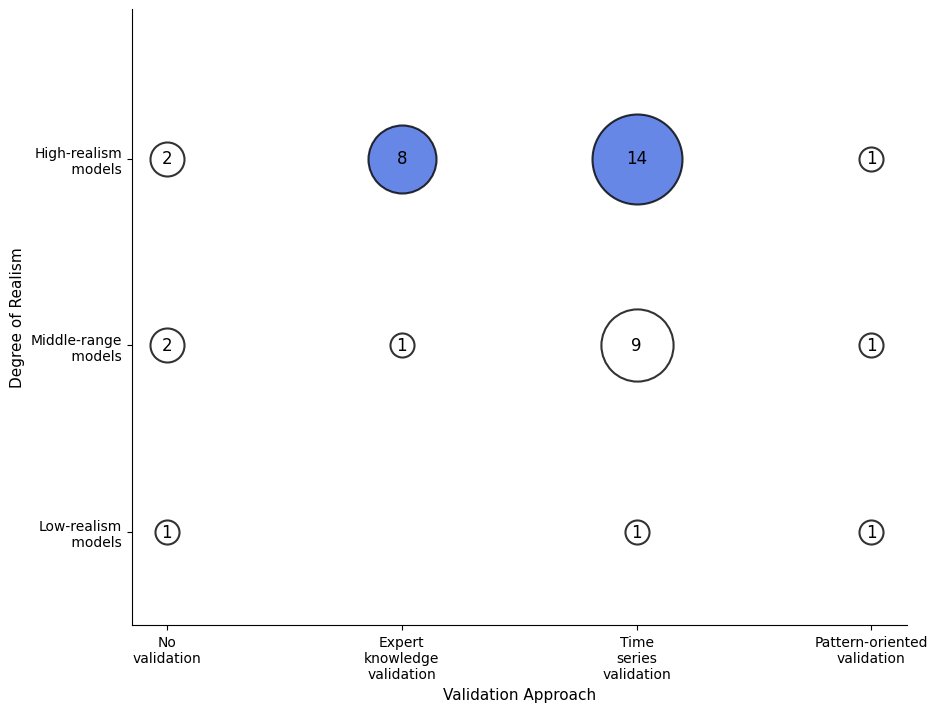

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ==========================================
# 1. Configuration and Paths
# ==========================================

# Base Paths (Uncomment the active path)
BASE_PATH = 'E:\\Projetos\\ABM-WP' # Currently active path

# Output Configuration
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FILENAME = "figure-classification-validation-fig14.pdf"

def main():
    print("--- Generating Classification Bubble Chart ---")

    # ==========================================
    # 2. Data Definition
    # ==========================================
    
    # Axis Labels
    validation_methods = ['No validation', 'Expert knowledge validation', 'Time series validation', 'Pattern-oriented validation']
    realism_degrees = ['Low-realism\n models', 'Middle-range\n models', 'High-realism\n models']

    # Data Matrix (from Sattler et al., 2023 - Figure 4)
    # Rows: Realism Degrees | Columns: Validation Methods
    data = np.array([
        [1, 0, 1, 1],   # Low-realism counts
        [2, 1, 9, 1],   # Middle-range counts
        [2, 8, 14, 1]   # High-realism counts
    ])

    # ==========================================
    # 3. Plotting
    # ==========================================
    
    # Create Figure
    fig, ax = plt.subplots(figsize=(10, 8))
    scale_factor = 300

    # Iterate through matrix to plot bubbles
    for i in range(len(realism_degrees)):
        for j in range(len(validation_methods)):
            count = data[i, j]
            if count > 0:
                # Default style
                color = 'white'
                edgecolor = 'black'
                zorder = 1
                
                # Highlight specific data points (ABM-WP Model Position)
                # Highlighting: High-realism (row 2) + Expert Knowledge (col 1) OR Time Series (col 2)
                if (j == 1 and i == 2) or (j == 2 and i == 2):
                    color = 'royalblue' 
                    edgecolor = 'black'
                    zorder = 3 # Draw on top

                # Plot the bubble
                ax.scatter(j, i, s=count * scale_factor, alpha=0.8, 
                           color=color, edgecolors=edgecolor, linewidth=1.5, zorder=zorder)
                
                # Add the count number inside the bubble
                ax.text(j, i, str(count), ha='center', va='center', 
                        fontsize=12, color='black', zorder=zorder+1)

    # ==========================================
    # 4. Axis and Layout Formatting
    # ==========================================
    
    # X-Axis
    ax.set_xticks(np.arange(len(validation_methods)))
    # Add line breaks to long labels for better readability
    ax.set_xticklabels([label.replace(' ', '\n') for label in validation_methods], fontsize=10)
    ax.set_xlabel('Validation Approach', fontsize=11)

    # Y-Axis
    ax.set_yticks(np.arange(len(realism_degrees)))
    ax.set_yticklabels(realism_degrees, fontsize=10)
    ax.set_ylabel('Degree of Realism', fontsize=11)

    # Title
    #title_text = "Classification of the research scenario in ABMs of water demand\nand positioning of the ABM-WP model"
    #ax.set_title(title_text, fontsize=14, pad=20, fontweight='bold')

    # Adjust Limits (to fit bubbles)
    ax.set_ylim(-0.5, 2.8)

    # Aesthetics (Remove top/right spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # ==========================================
    # 5. Saving
    # ==========================================
    
    # Ensure directory exists
    if not os.path.exists(OUTPUT_DIR):
        try:
            os.makedirs(OUTPUT_DIR)
            print(f"Directory created: {OUTPUT_DIR}")
        except OSError as e:
            print(f"Error creating directory: {e}")

    full_path = os.path.join(OUTPUT_DIR, OUTPUT_FILENAME)

    # Save as PDF (Vector format)
    plt.savefig(full_path, format='pdf', bbox_inches='tight')
    print(f"Chart successfully saved to: {full_path}")

    plt.show()

if __name__ == "__main__":
    main()